In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as transforms

# Viewing the high and low resolution images

In [2]:
lr_path = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution"
hr_path = "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_High_Resolution"
print(os.listdir(lr_path)[:5])

['agrivision_train_0772.png', 'agrivision_train_0802.png', 'agrivision_train_1205.png', 'agrivision_train_1566.png', 'agrivision_train_0518.png']


In [9]:
# Low resolution image
sample_file = sorted(os.listdir(lr_path))[0]
print(sample_file)

img = Image.open(os.path.join(lr_path, sample_file))

print(img.size)

agrivision_train_0000.png
(32, 32)


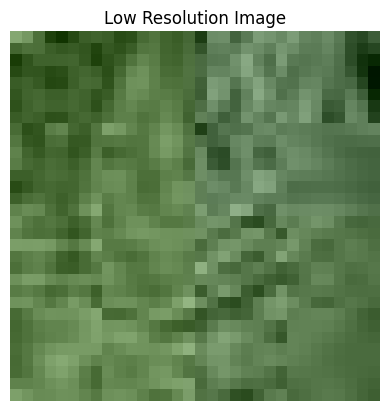

In [5]:
plt.imshow(img)
plt.title("Low Resolution Image")
plt.axis("off")
plt.show()

In [8]:
# Respective high resolution image
sample_file = sorted(os.listdir(hr_path))[0]
print(sample_file)
hr_img = Image.open(os.path.join(hr_path, sample_file))

print(hr_img.size)

agrivision_train_0000.png
(128, 128)


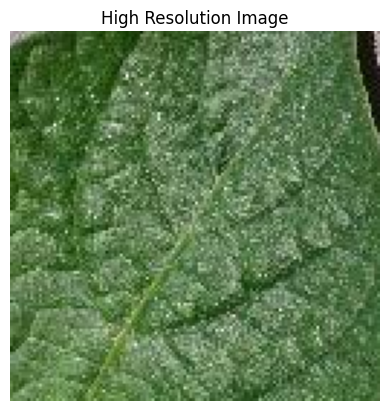

In [7]:
plt.imshow(hr_img)
plt.title("High Resolution Image")
plt.axis("off")
plt.show()

## Dataset Loader

In [ ]:
# Data Loader: It returns the high and low resolution images. 
class SuperResDataset(Dataset):
    def __init__(self, lr_dir, hr_dir=None):
        self.lr_dir = lr_dir
        self.hr_dir = hr_dir
        # Sorting is done to maintain the alighment od the high and low resolution images. 
        self.files = sorted(os.listdir(lr_dir))

        self.transform = transforms.ToTensor()
        # ToTensor converts the pixel values to float 
        # 0 - 0.0, 255 - 1.0 (divide each pixel value by 255 )

    def __len__(self):
        return len(self.files)

    # Used for accessing any image in the dataset. 
    def __getitem__(self, idx):
        lr_path = os.path.join(self.lr_dir, self.files[idx])
        lr = Image.open(lr_path).convert("RGB")        # 3 channel image
        lr = self.transform(lr)

        # Check if we are training or testing, for training HR exisits for testing it does not. 
        if self.hr_dir:
            hr_path = os.path.join(self.hr_dir, self.files[idx])
            hr = Image.open(hr_path).convert("RGB")
            hr = self.transform(hr)
            return lr, hr
        else:
            return lr, self.files[idx]

## Generator

In [ ]:
# Image Upscaling
class ResidualBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, 3, 1, 1),
            nn.ReLU(),
            nn.Conv2d(channels, channels, 3, 1, 1)
        )

    def forward(self, x):
        return x + self.block(x)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()

        # conv(in, out, ksize, stride, padding)
        self.conv1 = nn.Conv2d(3, 64, 9, 1, 4)

        # 16 residual blocks 
        self.res_blocks = nn.Sequential(
            *[ResidualBlock(64) for i in range(16)]
        )

        self.conv2 = nn.Conv2d(64, 64, 3, 1, 1)

        # Upsampling x4
        self.upsample = nn.Sequential(
            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.ReLU(),

            nn.Conv2d(64, 256, 3, 1, 1),
            nn.PixelShuffle(2),
            nn.ReLU(),
        )

        self.conv3 = nn.Conv2d(64, 3, 9, 1, 4)

    def forward(self, x):
        x1 = torch.relu(self.conv1(x))
        x2 = self.res_blocks(x1)
        x3 = self.conv2(x2) + x1
        x4 = self.upsample(x3)
        out = torch.sigmoid(self.conv3(x4)) 

        return out

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Generator().to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.L1Loss()  # MAE

In [ ]:
train_dataset = SuperResDataset(
    "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_Low_Resolution",
    "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/train_High_Resolution"
)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

## Loss Function

In [ ]:
epochs = 15

for epoch in range(epochs):
    total_loss = 0

    for lr, hr in tqdm(train_loader):
        lr, hr = lr.to(device), hr.to(device)

        pred = model(lr)

        loss = criterion(pred, hr)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch} Loss: {total_loss/len(train_loader):.4f}")

In [ ]:
test_dataset = SuperResDataset(
    "/kaggle/input/competitions/plant-leaves-super-resolution-challenge/test_Low_Resolution"
)

test_loader = DataLoader(test_dataset, batch_size=1, shuffle=False)

model.eval()

results = []

with torch.no_grad():
    for lr, name in tqdm(test_loader):

        lr = lr.to(device)

        sr = model(lr).cpu().numpy()[0]

        sr = np.clip(sr * 255, 0, 255).astype(np.uint8)

        # Convert CHW → HWC
        sr = np.transpose(sr, (1, 2, 0))

        # Flatten 
        flat = sr.flatten()

        pixel_str = " ".join(map(str, flat))

        results.append((name[0], pixel_str))

In [ ]:
df = pd.DataFrame(results, columns=["Id", "Pixels"])
df.to_csv("submission.csv", index=False)